In [61]:
!pip install mlxtend
!pip install scikit-learn

In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from torch.utils.data import DataLoader
import zipfile
import os
import seaborn as sns

# New imports for translating to pretrained model
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from sklearn.metrics import f1_score

In [63]:
# use gpu

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [64]:
# transform

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=16),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#seperate evaluation transform excluding augmentation
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
# extract dataset and load

zip_file_path = '/content/drive/MyDrive/its365/CIFAR-10-images-master.zip'
extracted_dir = '/mnt/data/extracted_cifar10'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_dir)

dataset_dir = os.path.join(extracted_dir, 'CIFAR-10-images-master')
test_dir = os.path.join(dataset_dir, 'test')
train_dir = os.path.join(dataset_dir, 'train')

full_dataset_train = torchvision.datasets.ImageFolder(train_dir,transform=train_transform)
full_dataset_eval = torchvision.datasets.ImageFolder(train_dir,transform=eval_transform)
dataset_test = torchvision.datasets.ImageFolder(test_dir,transform=eval_transform)

In [67]:
# stratified split from indices instead of random
indices = list(range(len(full_dataset_train)))
targets = full_dataset_train.targets

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=targets
)

# apply different transforms to each split
train_dataset = Subset(full_dataset_train, train_idx)
val_dataset = Subset(full_dataset_eval, val_idx)


# dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(dataset_test, batch_size=64, shuffle=False)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(dataset_test)}")

Train size: 40000
Val size: 10000
Test size: 10000


In [68]:
# init model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 10)

criterion = nn.CrossEntropyLoss()  # set CEL

# freeze to only train classifier
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3}
])

# ensure model uses gpu
model = model.to(device)

In [69]:
# training loop
num_epochs = 10
train_losses = []
val_losses = []

# keep track of 'best' model
best_val_loss = float("inf")
best_model_path = "best_resnet18_cifar10.pth"

# keep track of epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=2
)

# training pretrained model
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

# validate
model.eval()
val_running_loss = 0.0

with torch.no_grad():
  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    loss = criterion(outputs, labels)
    val_loss += loss.item() * images.size(0)

    val_loss = val_running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

# keep 'best' model
if val_loss < best_val_loss:
  best_val_loss = val_loss
  torch.save(model.state_dict(), best_model_path)

print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


Epoch 10/10, Train Loss: 0.2037, Val Loss: 0.0000


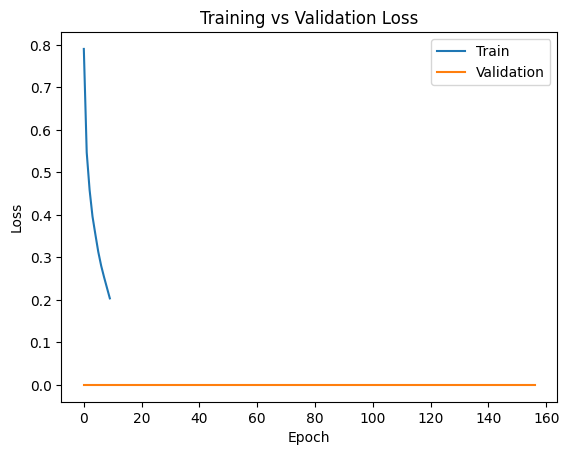

Validation Set Evaluation:
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      1000
           1       0.91      0.96      0.93      1000
           2       0.77      0.84      0.80      1000
           3       0.80      0.66      0.72      1000
           4       0.75      0.91      0.82      1000
           5       0.79      0.79      0.79      1000
           6       0.92      0.85      0.88      1000
           7       0.90      0.78      0.84      1000
           8       0.91      0.94      0.92      1000
           9       0.95      0.88      0.91      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000

Validation Confusion Matrix:
[[917   5  18   4   7   0   1   3  36   9]
 [  4 957   5   3   1   1   0   1  10  18]
 [ 37   2 841  24  49  15  18   9   5   0]
 [ 15   6  52 663  59 128  28  34  10   5]
 [  8   1  32

In [70]:
# plot train vs validation Loss
plt.plot(train_losses)
plt.plot(val_losses)
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

# classification report and confusion matrix
model.eval()
val_preds = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        val_preds.extend(predicted.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())

print("Validation Set Evaluation:")
print(classification_report(val_labels, val_preds))
print("Validation Confusion Matrix:")
print(confusion_matrix(val_labels, val_preds))


In [71]:
# set model to 'best' model
model.load_state_dict(torch.load(best_model_path))
model.eval()

# test set eval
model.eval()

test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

In [72]:
# print test classification and confusion matrix
print("Test Set Evaluation:")
print(classification_report(test_labels, test_preds))
print("Test Confusion Matrix:")
print(confusion_matrix(test_labels, test_preds))

Test Set Evaluation:
              precision    recall  f1-score   support

           0       0.87      0.90      0.88      1000
           1       0.90      0.94      0.92      1000
           2       0.78      0.84      0.81      1000
           3       0.77      0.61      0.68      1000
           4       0.73      0.90      0.80      1000
           5       0.78      0.79      0.78      1000
           6       0.91      0.86      0.89      1000
           7       0.91      0.78      0.84      1000
           8       0.90      0.95      0.92      1000
           9       0.94      0.88      0.91      1000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000

Test Confusion Matrix:
[[900   6  19   4  12   3   2   3  45   6]
 [ 11 937   6   1   0   1   0   1  15  28]
 [ 34   0 845  25  49   7  27   8   3   2]
 [ 17   6  54 613  81 148  34  27  13   7]
 [ 14   2  32  20 895  12

In [73]:
# more cleary print F1
macro_f1 = f1_score(test_labels, test_preds, average="macro")
weighted_f1 = f1_score(test_labels, test_preds, average="weighted")

print("Test Macro F1:", macro_f1)
print("Test Weighted F1:", weighted_f1)

Test Macro F1: 0.8437869619298475
Test Weighted F1: 0.8437869619298475


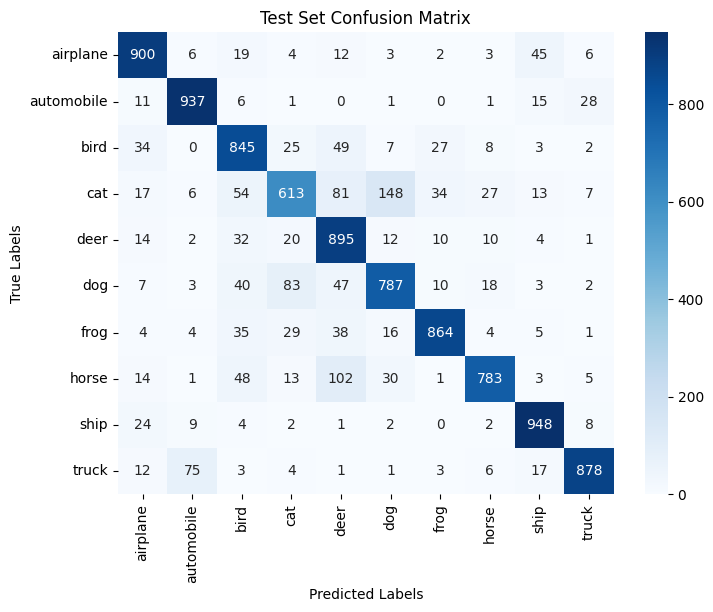

In [74]:
# plot confusion matrix to heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(test_labels, test_preds), annot=True, fmt='d', cmap='Blues', xticklabels=dataset_test.classes, yticklabels=dataset_test.classes)
plt.title("Test Set Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()